# Regressione Probabilistica tramite Processi Gaussiani (GPR)

In questa fase del progetto, l'obiettivo è modellare il **comportamento nominale** del motore aeronautico per definire un riferimento di "salute" della flotta. 
E' stata utilizzata la **Regressione tramite Processi Gaussiani (GPR)** per stimare la coppia target ($Trq_{margin}$) in base alle condizioni operative.

Il valore aggiunto di questo approccio è la capacità di fornire non solo una stima puntuale, ma una **distribuzione di probabilità** che permette di calcolare il **Torque Margin** e la relativa incertezza.

In [1]:
import os
import sys
import joblib
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path
from dataset import load_dataset
from regression.GPR.gpr_model import GPRModel
from regression.GPR.gpr_sampling import lhs_nearest_sampling
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [2]:

ROOT_DIR = Path(os.getcwd()).parents[3]
SRC_PATH = ROOT_DIR / "src"
DATA_PATH = ROOT_DIR / "data" / "processed"
OUTPUT_PATH = ROOT_DIR / "output" / "GPR" / "model_margin"
TRAIN_PATH_FULL="../../../../data/processed/full_train/train.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
MODEL_FILE = OUTPUT_PATH / "gpr_model.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"
OUTPUT_CSV = OUTPUT_PATH / "test_with_features_enriched.csv"
MODEL_FILE = OUTPUT_PATH / "gpr_model_20000.pkl"
SCALER_FILE = OUTPUT_PATH / "scaler_gpr.pkl"
# Aggiunta ROOT_DIR al path per permettere a joblib di trovare i moduli custom
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

In [3]:
FEATURES = ['oat', 'mgt', 'pa', 'ias', 'np_ng_ratio', 'trq_measured']
TARGET_COL = 'trq_margin'

In [5]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)

In [6]:
gpr_model = GPRModel(random_state=42)
if MODEL_FILE.exists() and SCALER_FILE.exists():
    print("Modello pre-addestrato trovato! Caricamento in corso...")
    try:
        gpr_model = joblib.load(MODEL_FILE)
        print("SUCCESSO: Modello e Scaler caricati correttamente.")
        addestramento_necessario = False
    except Exception as e:
        print(f"Errore nel caricamento dei file (file corrotti?): {e}")
        addestramento_necessario = True
else:
    print("Modello non trovato o incompleto. Avvio procedura di addestramento...")
    addestramento_necessario = True

# 3. Addestramento (solo se necessario)
if addestramento_necessario:
    # Campionamento LHS e Normalizzazione (5000 campioni per la massima precisione)
    X_train_scaled, y_train, scaler = lhs_nearest_sampling(
        train_df, FEATURES, TARGET_COL, n_samples=5000
    )

    # Fit del Modello GPR
    print("Addestramento GPR in corso (potrebbe richiedere qualche minuto)...")
    gpr_model = GPRModel(random_state=42)
    gpr_model.fit(X_train_scaled, y_train)

    # Salvataggio fisico
    OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
    try:
        joblib.dump(gpr_model, MODEL_FILE)
        print(f"SUCCESSO: Modello salvato in -> {MODEL_FILE}")
        print(f"SUCCESSO: Scaler salvato in -> {SCALER_FILE}")
    except Exception as e:
        print(f"ERRORE DURANTE IL SALVATAGGIO: {e}")

Modello non trovato o incompleto. Avvio procedura di addestramento...
Addestramento GPR in corso (potrebbe richiedere qualche minuto)...
SUCCESSO: Modello salvato in -> /Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/output/GPR/model_margin/gpr_model_20000.pkl
SUCCESSO: Scaler salvato in -> /Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/output/GPR/model_margin/scaler_gpr.pkl


/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
test_X=scaler.fit_transform(test_df[FEATURES])
test_y=test_df[TARGET_COL]

In [ ]:
gpr_model.evaluate(test_X,test_y)

0.1499872069269445


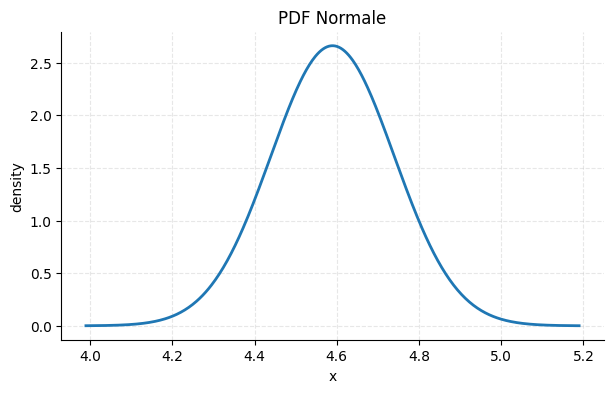

In [16]:
id =5682
test_row = test_X[id:id+1]
test_y_true = float(test_y[id])
mu, std = gpr_model.predict(test_row, return_std=True)
mu = float(mu[0])
std=float(std[0])

dist=stats.norm(mu,std)
print(std)
x = np.linspace(mu - 4*std, mu + 4*std, 500)
y = dist.pdf(x)
plt.figure(figsize=(7,4))
plt.plot(x, y, linewidth=2)
plt.title("PDF Normale")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(alpha=0.3)
plt.show()

pdf_args = {"loc": mu, "scale": std}

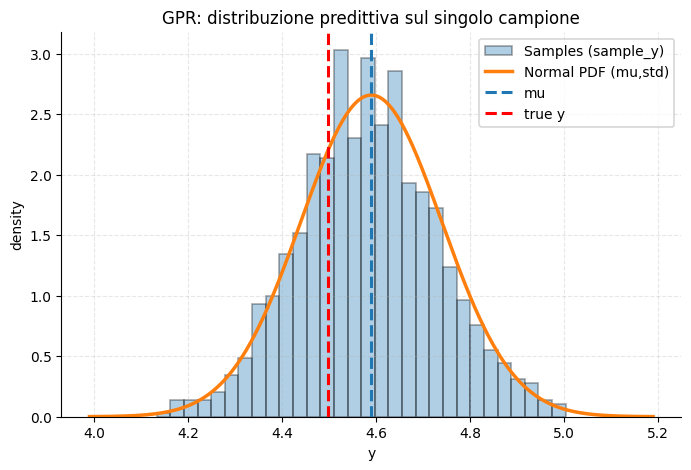

In [17]:

# 2) campioni dal GP in quel punto
n_draws = 1000
y_s = gpr_model.model.sample_y(test_row, n_samples=n_draws, random_state=0).ravel()  # (200,)

# 3) mu e std predittivi del GP nello stesso punto
mu1, std1 = gpr_model.model.predict(test_row, return_std=True)

# 4) PDF normale corrispondente
dist = stats.norm(loc=mu, scale=max(std, 1e-12))  # evita std=0
xx = np.linspace(mu - 4*std, mu + 4*std, 500) if std > 0 else np.linspace(mu-1, mu+1, 500)

# 5) plot: samples + pdf + true target
plt.figure(figsize=(8,5))

plt.hist(y_s, bins=30, density=True, alpha=0.35, label="Samples (sample_y)")
plt.plot(xx, dist.pdf(xx), lw=2.5, label="Normal PDF (mu,std)")

plt.axvline(mu, linestyle="--", label="mu")
plt.axvline(test_y_true, color="red", linestyle="--", label="true y")

plt.xlabel("y")
plt.ylabel("density")
plt.title("GPR: distribuzione predittiva sul singolo campione")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

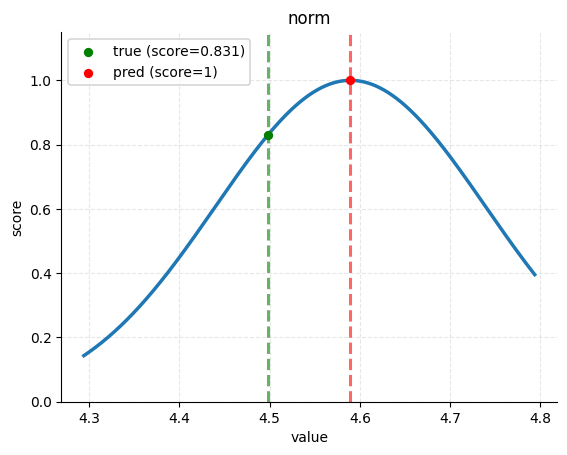

{'pdf_type': 'norm',
 'true_target': 4.498236296256844,
 'prediction': 4.58960696650754,
 'score_true': 0.8306480634054899,
 'score_pred': 1.000006996914192,
 'x_range': (4.293921631382192, 4.793921631382192)}

In [18]:
plot_pdf_with_true_target("norm",pdf_args,true_target=test_y_true,y_pred=mu)